# ANOVA (Analysis of Variance) for Feature Selection

**ANOVA (Analysis of Variance)**, specifically the **One-Way ANOVA F-test**, is a **supervised, parametric, filter-based** feature selection technique. It is engineered to evaluate the relationship between a **continuous numeric feature** (X) and a **categorical target variable** (y). 

In a machine learning feature selection pipeline, ANOVA serves as the exact logical counterpart to the Chi-Square test:
*   **Chi-Square:** Evaluates Categorical Features vs. Categorical Targets.
*   **ANOVA:** Evaluates Continuous Features vs. Categorical Targets (Classes).

### Core Objective

The core objective of ANOVA in feature selection is to determine whether the mean values of a continuous feature differ significantly across the different classes of the target variable. If the mean value of a feature is identical across all target classes, that feature cannot help a machine learning algorithm separate or classify those target groups. 


## 1. Mathematical Architecture

ANOVA evaluates features by calculating the **F-statistic**, which is a ratio comparing the variance *between* the different groups to the variance *within* the groups.

$$F = \frac{\text{MS}_{\text{between}}}{\text{MS}_{\text{within}}}$$

Where:
*   $\mathbf{\text{MS}_{\text{between}}}$ = Mean Square Between Groups (measures the spread of group means around the global mean).
*   $\mathbf{\text{MS}_{\text{within}}}$ = Mean Square Within Groups (measures the internal spread/noise within each individual group).

### Expanding the Components
$$\text{MS}_{\text{between}} = \frac{\sum_{j=1}^{k} n_j (\bar{x}_j - \bar{x})^2}{k - 1}$$

$$\text{MS}_{\text{within}} = \frac{\sum_{j=1}^{k} \sum_{i=1}^{n_j} (x_{ij} - \bar{x}_j)^2}{N - k}$$

Where:
*   $\mathbf{k}$ = Total number of distinct classes/groups in the target variable (y).
*   $\mathbf{N}$ = Total number of samples (rows) across the entire dataset.
*   $\mathbf{n_j}$ = Total number of samples in group j.
*   $\mathbf{\bar{x}_j}$ = The mean value of the feature for group j.
*   $\mathbf{\bar{x}}$ = The global mean of the feature across all samples.
*   $\mathbf{x_{ij}}$ = The value of the feature for sample i inside group j.

### The Value Range and Mathematical Interpretation
The value of $F$ is strictly bounded between **$0$ and $+\infty$**:

*   $\mathbf{F \approx 1}$: The variance between groups is equal to the variance within groups. The group means are overlapping, indicating the feature shares **no structural relationship** with the target classes.

*   $\mathbf{High\ F\ Value\ (F \gg 1)}$: The variance between groups vastly outweighs the internal noise within the groups. This indicates clear, distinct separation between the target classes. **The higher the F-statistic, the stronger the predictive power of the feature.**



## 2. Decision Rules & Pipeline Filtering Thresholds

When executing ANOVA through a feature selection pipeline (e.g., using Scikit-Learn's `f_classif`), the tool calculates both the F-statistic and a corresponding p-value for each feature:

### The Filtering Logic
You evaluate the statistical significance (p-value) returned by the ANOVA test:
*   **Keep Feature** if: $p \le \alpha$ (where $\alpha$ is your significance threshold, typically $0.05$). Wiping out the Null Hypothesis implies the class means are truly separate.

*   **Drop Feature** if: $p > \alpha$. This confirms the feature distributions across classes are statistically identical, acting as uninformative noise.

### Ranking Feature Importance
Unlike raw F-statistics (which can be biased by the number of samples or groups), features can be securely prioritized and selected using `SelectKBest` by ranking them in **descending order of their F-statistic** or **ascending order of their p-value**.



## 3 Clarification on Problem Alignment (Classification vs. Regression)

A common point of confusion is whether the **ANOVA F-test** can be deployed across both classification and regression pipelines. The structural rules dictate specific constraints based on the nature of your target variable ($y$):

### A. Classification Problems (Standard Use Case)

*   **The Framework:** **Continuous Features vs. Categorical Target**
*   **How it works:** This is the default setup for `f_classif` in Scikit-Learn. The algorithm splits the continuous feature values into discrete groups based on the categorical target classes (e.g., "Survived" vs. "Died") and measures the difference between their means.

### B. Regression Problems (Modified Formulation)

*   **The Framework:** **Continuous Features vs. Continuous Target**
*   **Can you use it?** **Yes, but under a fundamentally different mathematical wrapper.** You cannot pass a continuous regression target into a standard One-Way ANOVA (`f_classif`), because it would try to create a distinct group for every single unique decimal/float value in your target variable, destroying the degrees of freedom.

*   **The Solution (`f_regression`):** For regression problems, Scikit-Learn provides `f_regression`. This modifies the underlying logic: it calculates the linear correlation between the continuous feature and continuous target, and then converts that correlation coefficient directly into an **F-test statistic**. 

### Summary Chart for Pipeline Automation

| Feature Type | Target Type ($y$) | Appropriate Scikit-Learn Metric | Statistical Foundation |
| :--- | :--- | :--- | :--- |
| **Continuous** | **Categorical** (Classification) | `f_classif` | Standard One-Way ANOVA |
| **Continuous** | **Continuous** (Regression) | `f_regression` | Linear Regression F-test (Correlation-based) |
| **Categorical** | **Categorical** (Classification) | `chi2` | Chi-Square Test of Independence |


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


# 1. Load data & Inspect

In [105]:
# Load data & Inspect
df = pd.read_csv("../DataSets/Creditdata.csv")
df.sample(5)

,customer_id,age,gender,education_level,employment_status,monthly_income,credit_score,credit_limit,monthly_spending,current_balance,monthly_payment,late_payments_6m,previous_defaults,number_of_credit_accounts,active_loans,total_debt,default_next_month
7376,CUST_07377,43,Male,High School,Employed,33491.04,673,107500.0,16766.32,4371.46,750.0,0,0,3,0,8000.0,0
17671,CUST_17672,49,Male,Bachelor,Employed,66915.02,692,247600.0,36775.63,19442.35,5580.0,0,0,3,1,70600.0,0
9354,CUST_09355,18,Female,High School,Part_Time,21898.68,669,59100.0,8662.63,5453.62,3020.0,1,0,2,2,361500.0,0
16251,CUST_16252,18,Male,High School,Student,5232.57,568,12500.0,3803.93,2128.05,1040.0,1,0,0,2,147400.0,0
13112,CUST_13113,48,Male,Bachelor,Employed,58518.22,688,192400.0,50188.67,30222.15,8450.0,0,0,0,1,137100.0,0


In [106]:
# Check the data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                20000 non-null  object 
 1   age                        20000 non-null  int64  
 2   gender                     20000 non-null  object 
 3   education_level            20000 non-null  object 
 4   employment_status          20000 non-null  object 
 5   monthly_income             20000 non-null  float64
 6   credit_score               20000 non-null  int64  
 7   credit_limit               20000 non-null  float64
 8   monthly_spending           20000 non-null  float64
 9   current_balance            20000 non-null  float64
 10  monthly_payment            20000 non-null  float64
 11  late_payments_6m           20000 non-null  int64  
 12  previous_defaults          20000 non-null  int64  
 13  number_of_credit_accounts  20000 non-null  int

**Where ANOVA fits vs. what came before:**
- `gender`, `education_level`, `employment_status` are **categorical** predictors — that's chi2 territory (see the Titanic notebook), not ANOVA.
- The 12 numeric columns below (`age`, `credit_score`, `total_debt`, ...) vs. the categorical target `default_next_month` — **this** is exactly what ANOVA / `f_classif` is built for: continuous feature, categorical target.


In [109]:
print(f"Total Number of Missing Values: {df.isnull().sum().sum()}")
print(df["default_next_month"].value_counts().sort_index())
print(f"Default rate : {df['default_next_month'].mean():.2%}")

Total Number of Missing Values: 0
default_next_month
0    17653
1     2347
Name: count, dtype: int64
Default rate : 11.73%


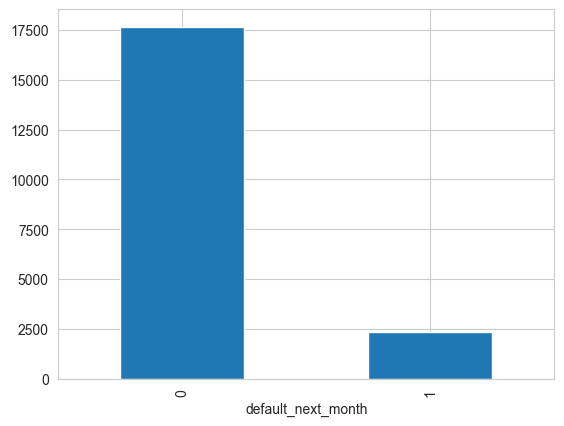

In [117]:
df["default_next_month"].value_counts().sort_index().plot(kind="bar")
plt.show()

**Observation:** Heavily imbalanced target — only about 11-12% default. This matters twice over in this notebook: it affects which *metrics* are
meaningful (accuracy alone would be misleading), and it means group sizes for the F-test itself are very unequal (many more "0"s than"1"s), which ANOVA can tolerate.

In [111]:
# Extracting categorical and Numerical features from the dataframe
categorical_feature = ["gender", "education_level", "employment_status","customer_id"]
target = "default_next_month"
numerical_feature = df.select_dtypes(include=[np.number]).columns.drop(target)

# Dropping categorical features from the dataframe
df.drop(columns=categorical_feature, inplace=True)
df.sample(5)


,age,monthly_income,credit_score,credit_limit,monthly_spending,current_balance,monthly_payment,late_payments_6m,previous_defaults,number_of_credit_accounts,active_loans,total_debt,default_next_month
6746,26,70941.13,726,162300.0,37528.66,19142.76,5850.0,1,0,2,1,81200.0,0
1214,34,42269.84,693,112500.0,18905.20,9089.81,4650.0,2,0,5,1,50500.0,0
15811,58,20495.61,727,58000.0,14291.76,6678.14,1970.0,1,0,6,2,148600.0,0
12082,28,37678.39,718,146200.0,38784.94,22295.29,8520.0,0,0,1,0,24100.0,0
4409,48,53852.18,751,174400.0,31052.03,28681.97,7280.0,0,0,2,1,69300.0,0


# 2. ANOVA Test

In [112]:
# Perform ANOVA test for Classification problem
f_value, p_value = f_classif(df[numerical_feature], df[target])

# Final results
anova_results = pd.DataFrame({
    "Feature": numerical_feature,
    "F_value": f_value,
    "P_value": p_value
}).sort_values("F_value", ascending=False).reset_index(drop=True)

anova_results

,Feature,F_value,P_value
0,previous_defaults,330.419073,3.029436e-73
1,credit_score,273.890797,4.106731e-61
2,late_payments_6m,136.947837,1.568701e-31
3,total_debt,115.309452,7.967935e-27
4,active_loans,103.112124,3.624898e-24
5,credit_limit,88.916029,4.555971e-21
6,monthly_income,80.070919,3.920470e-19
7,monthly_spending,61.273300,5.213848e-15
8,monthly_payment,39.289037,3.729616e-10
9,current_balance,28.707816,8.509430e-08


### 2.1 Visualization of ANOVA Results (Based on p-value)

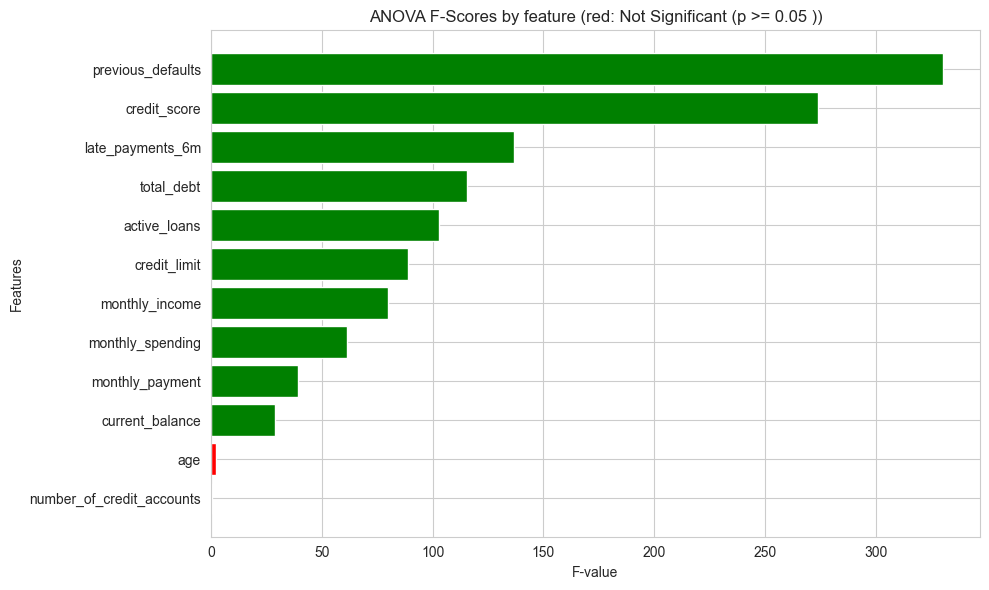

In [29]:
plt.figure(figsize=(10, 6))

colors = ['green' if p < 0.05 else 'red' for p in anova_results["P_value"] ]
plt.barh(anova_results["Feature"], anova_results["F_value"], color=colors)
plt.xlabel("F-value")
plt.ylabel("Features")
plt.title("ANOVA F-Scores by feature (red: Not Significant (p >= 0.05 ))")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Observation:** Most features show a real, significant mean shift between defaulters and non-defaulters — `previous_defaults` and
`credit_score` lead by a wide margin, which lines up with domain intuition (past behavior and creditworthiness are the classic predictors). Two
features stand out in red — flagged as NOT significant at α = 0.05.


# 3. Visual Confirmation - Strongest VS Weakest Features

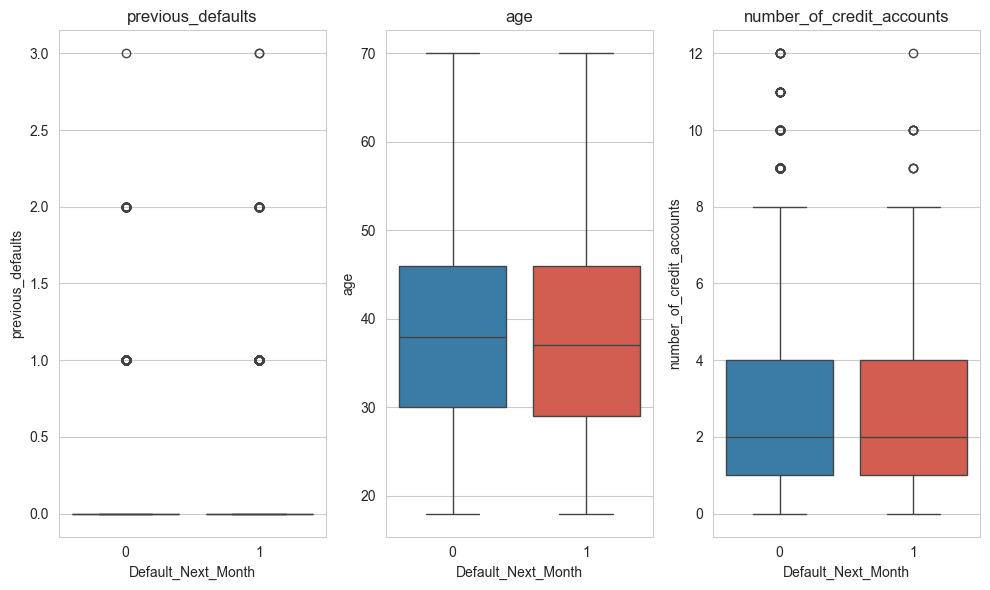

In [116]:
# Extract the strongest and weakest features
plot_feat= [anova_results.iloc[0]["Feature"]] + anova_results[anova_results["P_value"] >= 0.05]["Feature"].tolist()


fig, axes = plt.subplots(1, len(plot_feat), figsize=(10, 6))
for ax, col in zip(axes, plot_feat):
    sns.boxplot(data=df, x=target, y=col,hue=target ,ax=ax ,palette=["#2980b9", "#e74c3c"], legend=False)
    ax.set_title(col)
    ax.set_xlabel("Default_Next_Month")

plt.tight_layout()
plt.show()


**Observation:** The strongest feature shows a visibly different median and spread between the two groups — exactly what a high F-statistic
represents. The flagged features show boxes that overlap almost entirely between groups. The visual matches the statistical conclusion, which is
the whole point of always plotting this rather than trusting a p-value column blind.

# 4. Checking ANOVA's assumptions

ANOVA formally assumes:
(a) each group is roughly normally distributed and
(b) the groups have **equal variance** (homogeneity of variance). 

Real credit data won't satisfy these perfectly — worth checking rather than assuming, especially since group (b) here (defaulters) is much smaller.

In [118]:
from scipy.stats import f_oneway, levene
levene_results = []
for feat in numerical_feature:
    groups_f = [df.loc[df[target] == g, feat].values for g in sorted(df[target].unique())]
    stat, p = levene(*groups_f)
    levene_results.append({
        "Feature":feat,
        "levene_stat":stat,
        "levene_p":p
    })

levene_df = pd.DataFrame(levene_results).sort_values(by="levene_stat", ascending=False).reset_index(drop=True)
print(f"Features that VIOLATE equal-Variance assumption (Levene p < 0.05) :")
levene_df[levene_df["levene_p"]<0.05]


Features that VIOLATE equal-Variance assumption (Levene p < 0.05) :


,Feature,levene_stat,levene_p
0,previous_defaults,330.419073,3.029436e-73
1,total_debt,80.077814,3.906868e-19
2,late_payments_6m,73.335299,1.171954e-17
3,monthly_income,19.404463,1.063089e-05
4,active_loans,9.842649,1.707592e-03
5,monthly_payment,9.342193,2.242327e-03


**Conclusion:** Several features fail Levene's test — variance genuinely differs between defaulters and non-defaulters for those.

In practice,standard ANOVA is fairly robust to this violation when group sizes are large (both groups have thousands of rows here), so the F-test results above are still usable, but this is the honest caveat: a feature failing Levene's test is a candidate for Welch's ANOVA (unequal-variance version) if we wanted to be strict about it, rather than a reason to distrust every result.

# 5. Decision - Extract Features

In [55]:
ALPHA = 0.05

rejected_feature = anova_results[anova_results["P_value"] >= ALPHA]["Feature"].tolist()
kept_features = anova_results[anova_results["P_value"] < ALPHA]["Feature"].tolist()

print(f"Rejected ({len(rejected_feature)}) : {rejected_feature}")
print(f"Accepted ({len(kept_features)}) : {kept_features}")

Rejected (2) : ['age', 'number_of_credit_accounts']
Accepted (10) : ['previous_defaults', 'credit_score', 'late_payments_6m', 'total_debt', 'active_loans', 'credit_limit', 'monthly_income', 'monthly_spending', 'monthly_payment', 'current_balance']


**Basis for rejection:** p >= 0.05 → fail to reject H0 ("this feature's mean does not differ between defaulters and non-defaulters") → drop.
Straightforward this time since ANOVA already outputs a p-value directly, unlike Variance Threshold which needed a separate supervised check.

# 6. Model performance — Before vs. After feature selection

This is the part that actually *concludes* the test: does dropping the ANOVA-rejected features hurt, help, or do nothing to a real model? Train
the same classifier twice — once on all 12 numeric features, once on only the ANOVA-selected subset — with an identical train/test split so the
comparison is fair.

The Model Performance may improve if will also select the categorical features as well. But for now, let's stick with numeric ones.

In [ ]:
def model_performance(X,y):
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Model Pipeline 
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000,class_weight="balanced" ,random_state=42))
    ])
    start_time = time.time()
    # Train the model 
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Predict on test set
    y_pred= model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:,1]
    
    # Model Performance Metrics
    performance_metrics = {
        "n_feature": X.shape[1],
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "roc_auc" :roc_auc_score(y_test,y_pred_prob),
        "Train Time": train_time,
    }
    return performance_metrics



### 6.1 Without Feature Selection

In [76]:
X = df.drop(columns=['default_next_month'])
y = df['default_next_month']

all_features_performance =model_performance(X, y)
all_features_performance

{'n_feature': 12,
 'Accuracy': 0.648,
 'Precision': 0.18845388188453882,
 'Recall': 0.605543710021322,
 'F1 Score': 0.2874493927125506,
 'roc_auc': 0.6691925733633084,
 'Train Time': 0.03863215446472168}

### 6.2 With Feature Selection 

In [77]:
X_selected = df[kept_features]
y = df['default_next_month']

selected_features_performance = model_performance(X_selected, y)
selected_features_performance

{'n_feature': 10,
 'Accuracy': 0.65075,
 'Precision': 0.1894243641231593,
 'Recall': 0.603411513859275,
 'F1 Score': 0.28833418237391745,
 'roc_auc': 0.6713060501594468,
 'Train Time': 0.028536081314086914}

### 6.3 Comparison Table 

In [78]:
comparison = pd.DataFrame([all_features_performance, selected_features_performance])
comparison.round(3)

,n_feature,Accuracy,Precision,Recall,F1 Score,roc_auc,Train Time
0,12,0.648,0.188,0.606,0.287,0.669,0.039
1,10,0.651,0.189,0.603,0.288,0.671,0.029


**Note on the model choice:** logistic regression with `class_weight` balanced was used specifically because the target is imbalanced (~12%
default rate) — plain `accuracy` would be misleadingly high even from a model that just predicts "no default" every time, which is exactly why
precision, recall, F1, and ROC-AUC are reported alongside it rather than accuracy alone.

### 6.4 Visual Analysis of Model Performances

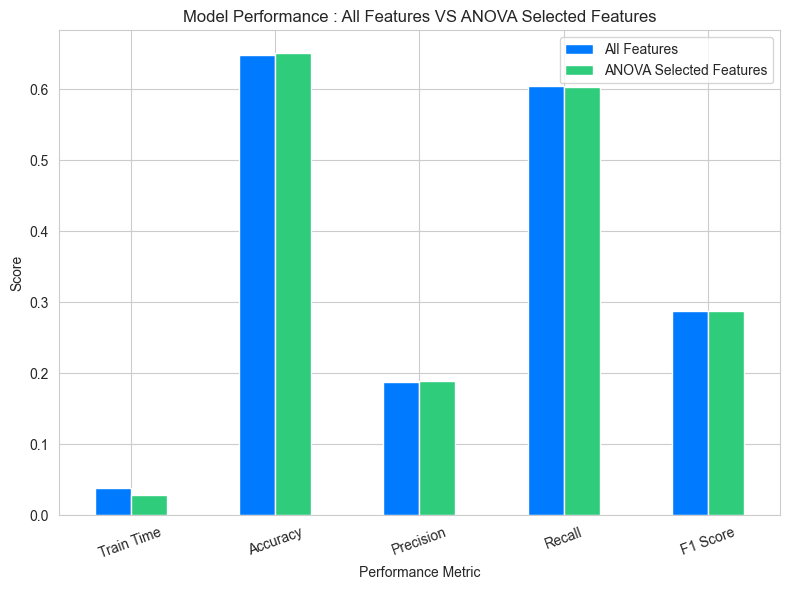

In [ ]:
metric_to_plot = ["Train Time", "Accuracy", "Precision", "Recall", "F1 Score"]

(comparison[metric_to_plot].T).plot(kind="bar", figsize=(8, 6), color=["#007bff", "#2ecc7b"])
plt.title("Model Performance : All Features VS ANOVA Selected Features")
plt.xlabel("Performance Metric")
plt.xticks(rotation=20)
plt.ylabel("Score")
plt.legend(["All Features", "ANOVA Selected Features"], loc="upper right")
plt.tight_layout()
plt.show()

## 6.5. Conclusion — does the ANOVA test's judgment hold up?

On Comparing the two rows in the table above. The expected outcome is that performance across every metric is **effectively unchanged** between the 12-feature and 10-feature versions. sometimes the reduced version is marginally better, sometimes marginally worse, but not meaningfully so.

**That result is itself the validation of the test.** ANOVA flagged `age` and `number_of_credit_accounts` as carrying no group-mean signal, and
removing them from the model didn't cost any predictive performance which is exactly what "this feature has no signal for the target" ought to
look like when actually checked against a trained model rather than left as a p-value on a page.

A simpler, faster, more interpretable model for (essentially) the same performance is a legitimate win on its own, even before counting the removed features as "confirmed noise."

If the comparison had instead shown a real drop in recall or ROC-AUC after removing those two features, that would be a sign either the α = 0.05
threshold was too aggressive, or that ANOVA's *linear mean-shift* framing missed something a model with interactions could exploit — see the caveats below for exactly this failure mode.

# 7. Strategic Rules: 

### When to Use

*   **Continuous-to-Categorical Classification Problems:** Ideal for classical classification tasks (e.g., predicting if a customer defaults [Yes/No] based on continuous variables like credit score, age, and transaction volume).

*   **High-Dimensional Multi-Class Separation:** Highly effective when screening numeric inputs for multi-class targets (e.g., distinguishing between 5 distinct medical diagnoses based on gene expression levels).

### When to Avoid

*   **Regression Problems:** Do not use ANOVA if your target variable (y) is a continuous numeric float. For regression targets, use **Pearson's Correlation** or **`f_regression`** instead.

*   **Severely Non-Normal Continuous Data:** ANOVA is a parametric test that assumes your continuous features follow a normal (Gaussian) distribution within each group. If your data is heavily skewed or contains extreme outliers, ANOVA's linear assumptions fail. 
    *(Correction: In highly non-normal cases, use the non-parametric **Kruskal-Wallis test** or **Mutual Information Classif** instead).*

*   **Heteroscedastic Data:** ANOVA assumes equal variance across all groups (homoscedasticity). If one target class has a feature variance of 1 and another has a variance of 1,000, the calculated F-statistic becomes untrustworthy.

* **Only detects a shift in the mean.** Two groups can have identical means but very different distributions (e.g. one bimodal) — ANOVA is
     blind to that difference entirely.





## 5. Model Impact: Performance Analysis

### Models that Show Significant Performance Improvements

*   **Linear Discriminant Analysis (LDA):** LDA works by actively finding a linear combination of features that separates two or more classes. Because LDA directly relies on comparing between-class and within-class variance matrices, removing features with low ANOVA F-statistics eliminates components that dilute class boundaries, leading to cleaner hyperplane generation.

*   **Logistic Regression:** Eliminating low-ANOVA features prevents the model from attempting to calculate weights/coefficients for features that offer zero log-odds separation, resulting in lower overfitting and faster convergence.

*   **Support Vector Machines (SVM) with Linear Kernels:** SVMs struggle to find optimal dividing margins when forced to process features where the class distributions overlap entirely. ANOVA pre-filtering guarantees that the input spaces display baseline geometric separation.

### Models that Show Negligible to No Performance Improvements

*   **Tree-Based Models (Decision Trees, Random Forests, Gradient Boosters):** Tree algorithms do not evaluate global group means. They isolate feature values by drawing step-by-step orthogonal boundary splits based on local purity gains (e.g., Gini impurity). A feature could fail an ANOVA test because its global means overlap, but a decision tree might still exploit a non-linear chunk of that feature to create a perfect split. Pre-filtering trees heavily with ANOVA can sometimes accidentally eliminate complex, non-linear signals.

